In [1]:
#EXERCICE 2 
#A)
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# I'm just putting the concentrations of the total lactic acid (g/L) and specific growth rate (h^-1), respectively, in arrays.
p_gL = np.array([0.0, 12.0, 39.0, 55.0])      
mu = np.array([0.9, 0.68, 0.52, 0.13])

pH = 6.3
pKa = 3.88
M_lactic = 90.08 #g/mol

Ctot = p_gL / M_lactic #I'm converting the concentrations of the total lactic acid to mol/L

#I'm determining the concentration of the undissociated acid [HA]
ratio = 10**(pH - pKa)            # ration is basically [A-]/[HA]
P = Ctot / (1 + ratio)            # P is the undissociated concentration

mu_rel = mu / mu[0]    #This is the relative specific growth rate

Undissociated lactic acid concentration P (mol/L):
total acid =   0.0 g/L   P = 0.000000 mol/L   mu/mu0 = 1.0000
total acid =  12.0 g/L   P = 0.000505 mol/L   mu/mu0 = 0.7556
total acid =  39.0 g/L   P = 0.001640 mol/L   mu/mu0 = 0.5778
total acid =  55.0 g/L   P = 0.002313 mol/L   mu/mu0 = 0.1444


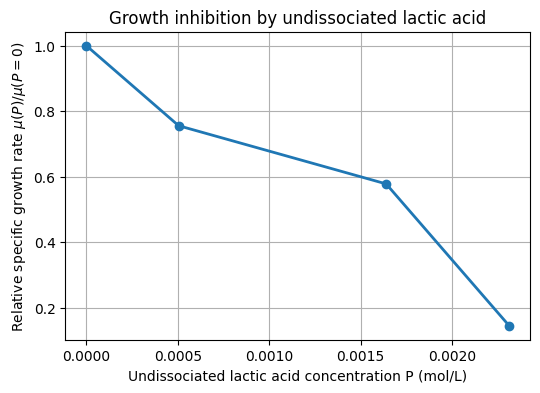

In [3]:
print("Undissociated lactic acid concentration P (mol/L):")
for p_tot, p_undiss, mu_r in zip(p_gL, P, mu_rel):
    print(f"total acid = {p_tot:5.1f} g/L   P = {p_undiss:.6f} mol/L   mu/mu0 = {mu_r:.4f}")

#We plot the relative specific growth rate :
plt.figure(figsize=(6,4))
plt.plot(P, mu_rel, 'o-', linewidth=2)
plt.xlabel("Undissociated lactic acid concentration P (mol/L)")
plt.ylabel(r"Relative specific growth rate $\mu(P)/\mu(P=0)$")
plt.title("Growth inhibition by undissociated lactic acid")
plt.grid(True)
plt.show()

In [4]:
# 5) Because substrate is saturating: mu = mu_max / (1 + P/KI)
#    and at P = 0, we have mu(0) = mu_max
mu_max = mu[0]

# 6) Linearization:
#    mu_max/mu = 1 + P/KI
#    => y = mu_max/mu - 1 = (1/KI) * P
x = P
y = mu_max / mu - 1

In [5]:
# Linear fit with polyfit: y = a*x + b
a, b = np.polyfit(x, y, 1)

KI = 1 / a

print(f"mu_max = {mu_max:.4f} h^-1")
print(f"slope = {a:.6f} L/mol")
print(f"intercept = {b:.6f}")
print(f"KI = {KI:.6f} mol/L")

mu_max = 0.9000 h^-1
slope = 2190.602968 L/mol
intercept = -0.696462
KI = 0.000456 mol/L


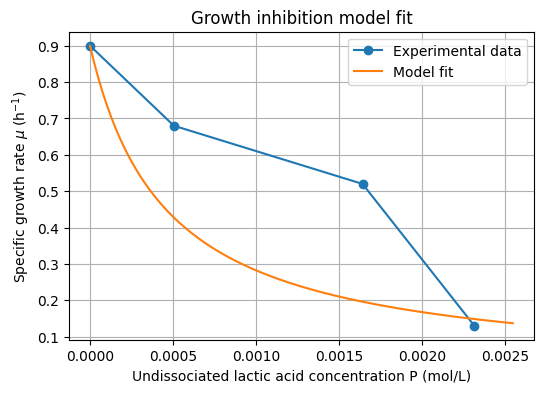

In [6]:
# 7) Model prediction
P_model = np.linspace(0, max(P)*1.1, 200)
mu_model = mu_max / (1 + P_model / KI)

# 8) Plot experimental data + model
plt.figure(figsize=(6,4))
plt.plot(P, mu, 'o-', label='Experimental data')
plt.plot(P_model, mu_model, '-', label='Model fit')
plt.xlabel("Undissociated lactic acid concentration P (mol/L)")
plt.ylabel(r"Specific growth rate $\mu$ (h$^{-1}$)")
plt.title("Growth inhibition model fit")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
#C

In [8]:
# Second model : mu = mu_max * (1 - P/Pmax)
# y = a*x + b, with a = -1/Pmax and b = 1

In [9]:
x2 = P
y2 = mu / mu_max

a2, b2 = np.polyfit(x2, y2, 1)

Pmax = -1 / a2

print(f"slope = {a2:.6f} L/mol")
print(f"intercept = {b2:.6f}")
print(f"Pmax = {Pmax:.6f} mol/L")

slope = -330.221495 L/mol
intercept = 0.987383
Pmax = 0.003028 mol/L


SSE model 1 (1 / (1 + P/KI)) = 0.169079
SSE model 2 (1 - P/Pmax)     = 0.023272


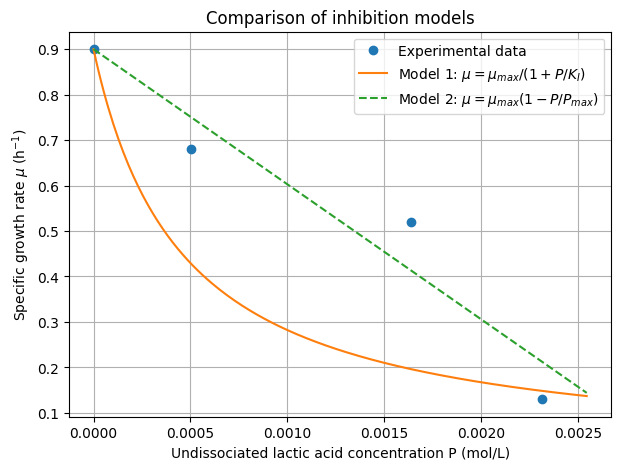

In [10]:
mu_model_1 = mu_max / (1 + P_model / KI)          # previous model
mu_model_2 = mu_max * (1 - P_model / Pmax)        # linear inhibition model

# Remove negative values for physical meaning
mu_model_2 = np.maximum(mu_model_2, 0)

# We will predict the values of mu at the experimental point and then compare theme to the real measured values.
mu_pred_1 = mu_max / (1 + P / KI)
mu_pred_2 = mu_max * (1 - P / Pmax)
mu_pred_2 = np.maximum(mu_pred_2, 0)

# Sum of squared errors
SSE_1 = np.sum((mu - mu_pred_1)**2)
SSE_2 = np.sum((mu - mu_pred_2)**2)


print(f"SSE model 1 (1 / (1 + P/KI)) = {SSE_1:.6f}")
print(f"SSE model 2 (1 - P/Pmax)     = {SSE_2:.6f}")

# teh Plot : 
plt.figure(figsize=(7,5))
plt.plot(P, mu, 'o', label='Experimental data')
plt.plot(P_model, mu_model_1, '-', label='Model 1: $\\mu=\\mu_{max}/(1+P/K_I)$')
plt.plot(P_model, mu_model_2, '--', label='Model 2: $\\mu=\\mu_{max}(1-P/P_{max})$')
plt.xlabel("Undissociated lactic acid concentration P (mol/L)")
plt.ylabel(r"Specific growth rate $\mu$ (h$^{-1}$)")
plt.title("Comparison of inhibition models")
plt.grid(True)
plt.legend()
plt.show()

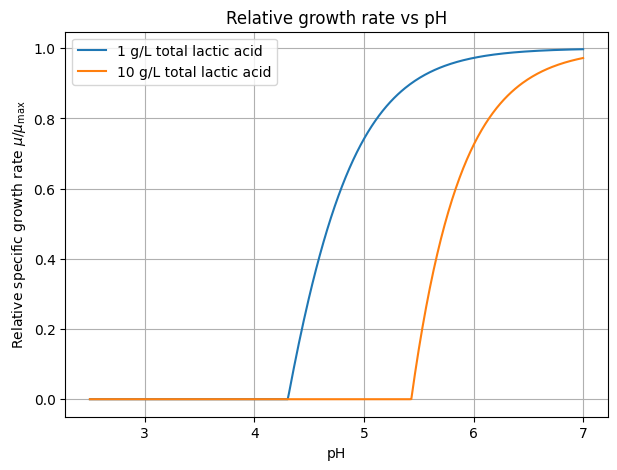

pH where growth stops for 1 g/L  = 4.305838831913449
pH where growth stops for 10 g/L = 5.4321654048672725


In [11]:
# pH range
pH_values = np.linspace(2.5, 7.0, 400)

# total acid in g/L
p_total_gL_1 = 1.0
p_total_gL_10 = 10.0

# g/L to mol/L
Ctot_1 = p_total_gL_1 / M_lactic
Ctot_10 = p_total_gL_10 / M_lactic

# undissociated acid
P_1 = Ctot_1 / (1 + 10**(pH_values - pKa))
P_10 = Ctot_10 / (1 + 10**(pH_values - pKa))

# relative growth
mu_rel_1 = np.maximum(1 - P_1 / Pmax, 0)
mu_rel_10 = np.maximum(1 - P_10 / Pmax, 0)

# plot
plt.figure(figsize=(7,5))
plt.plot(pH_values, mu_rel_1, label='1 g/L total lactic acid')
plt.plot(pH_values, mu_rel_10, label='10 g/L total lactic acid')
plt.xlabel("pH")
plt.ylabel(r"Relative specific growth rate $\mu / \mu_{\max}$")
plt.title("Relative growth rate vs pH")
plt.grid(True)
plt.legend()
plt.show()

# pH where growth stops
# condition: P = Pmax
# Pmax = Ctot / (1 + 10^(pH - pKa))
# 10^(pH - pKa) = Ctot/Pmax - 1
# pH = pKa + log10(Ctot/Pmax - 1)

def pH_stop(Ctot, Pmax, pKa):
    value = Ctot / Pmax - 1
    if value > 0:
        return pKa + np.log10(value)
    else:
        return None

pH_stop_1 = pH_stop(Ctot_1, Pmax, pKa)
pH_stop_10 = pH_stop(Ctot_10, Pmax, pKa)

print(f"pH where growth stops for 1 g/L  = {pH_stop_1}")
print(f"pH where growth stops for 10 g/L = {pH_stop_10}")